# 02 — Bowling Analysis
## AuctionIQ — IPL Player Valuation & Auction Intelligence
**Goal:** Calculate comprehensive bowling statistics for every IPL bowler — economy rate, wicket rate, dot ball %, phase-wise performance, and build a Bowling Performance Index (BoPI).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11

# Load master data
master = pd.read_csv('../data/processed/master_balls.csv')
master['season'] = master['season'].astype(str)
master['phase']  = master['ball'].apply(
    lambda b: 'Powerplay' if int(float(b)) < 6
    else ('Middle' if int(float(b)) < 15 else 'Death')
)

print(f"✅ Data loaded")
print(f"   Balls   : {len(master):,}")
print(f"   Bowlers : {master['bowler'].nunique():,}")

✅ Data loaded
   Balls   : 287,513
   Bowlers : 569


In [2]:
# Legal deliveries for economy (exclude wides and noballs)
legal = master[master['wides'].isna() & master['noballs'].isna()].copy()

# All deliveries for wickets (wides can take wickets)
all_balls = master.copy()

# Core bowling stats
bowling_legal = legal.groupby('bowler').agg(
    legal_balls  = ('ball', 'count'),
    runs_conceded= ('runs_off_bat', 'sum'),
    dot_balls    = ('runs_off_bat', lambda x: (x == 0).sum()),
    fours_hit    = ('runs_off_bat', lambda x: (x == 4).sum()),
    sixes_hit    = ('runs_off_bat', lambda x: (x == 6).sum()),
).reset_index()

# Wickets — from all deliveries
bowling_wickets = all_balls[
    all_balls['wicket_type'].notna() &
    ~all_balls['wicket_type'].isin(['run out', 'retired hurt', 'obstructing the field'])
].groupby('bowler').agg(
    wickets = ('wicket_type', 'count')
).reset_index()

# Matches bowled
matches = master.groupby('bowler')['match_id'].nunique().reset_index()
matches.columns = ['bowler', 'matches']

# Combine
bowling = bowling_legal.merge(bowling_wickets, on='bowler', how='left')
bowling = bowling.merge(matches, on='bowler', how='left')
bowling['wickets'] = bowling['wickets'].fillna(0).astype(int)

# Derived metrics
bowling['overs']       = (bowling['legal_balls'] / 6).round(1)
bowling['economy']     = (bowling['runs_conceded'] / bowling['overs']).round(2)
bowling['wicket_rate'] = (bowling['legal_balls'] / bowling['wickets'].replace(0, np.nan)).round(2)
bowling['dot_pct']     = (bowling['dot_balls'] / bowling['legal_balls'] * 100).round(2)
bowling['boundary_pct']= ((bowling['fours_hit'] + bowling['sixes_hit']) / bowling['legal_balls'] * 100).round(2)
bowling['avg']         = (bowling['runs_conceded'] / bowling['wickets'].replace(0, np.nan)).round(2)

# Filter — minimum 20 matches
bowling = bowling[bowling['matches'] >= 20].copy()

print(f"✅ Bowling stats calculated")
print(f"   Bowlers with 20+ matches: {len(bowling)}")
print(f"\nTop 10 wicket takers:")
print(bowling.nlargest(10, 'wickets')[
    ['bowler','matches','overs','wickets','economy','wicket_rate','dot_pct']
].to_string(index=False))

✅ Bowling stats calculated
   Bowlers with 20+ matches: 195

Top 10 wicket takers:
    bowler  matches  overs  wickets  economy  wicket_rate  dot_pct
 YS Chahal      179  656.8      228     7.78        17.29    34.33
   B Kumar      198  734.7      212     7.39        20.79    43.65
 SP Narine      194  752.7      201     6.66        22.47    39.64
 PP Chawla      191  641.7      192     7.83        20.05    35.27
 JJ Bumrah      152  585.8      188     6.96        18.70    42.30
  R Ashwin      217  785.0      187     6.95        25.19    35.31
  DJ Bravo      158  520.0      183     8.00        17.05    33.78
 RA Jadeja      232  695.0      176     7.51        23.69    33.00
  A Mishra      162  561.8      174     7.20        19.37    36.19
SL Malinga      122  471.2      170     6.74        16.63    43.05


In [3]:
# Phase-wise bowling stats — critical for auction valuation
phase_bowling = legal.groupby(['bowler', 'phase']).agg(
    balls        = ('ball', 'count'),
    runs         = ('runs_off_bat', 'sum'),
    dot_balls    = ('runs_off_bat', lambda x: (x == 0).sum()),
).reset_index()

# Phase wickets
phase_wickets = all_balls[
    all_balls['wicket_type'].notna() &
    ~all_balls['wicket_type'].isin(['run out','retired hurt','obstructing the field'])
].groupby(['bowler','phase']).agg(
    wickets = ('wicket_type', 'count')
).reset_index()

phase_bowling = phase_bowling.merge(phase_wickets, on=['bowler','phase'], how='left')
phase_bowling['wickets']  = phase_bowling['wickets'].fillna(0).astype(int)
phase_bowling['economy']  = (phase_bowling['runs'] / (phase_bowling['balls']/6)).round(2)
phase_bowling['dot_pct']  = (phase_bowling['dot_balls'] / phase_bowling['balls'] * 100).round(2)
phase_bowling['wicket_rate'] = (phase_bowling['balls'] / phase_bowling['wickets'].replace(0, np.nan)).round(2)

# Pivot to wide format
phase_pivot = phase_bowling.pivot_table(
    index='bowler',
    columns='phase',
    values=['economy', 'dot_pct', 'wickets'],
    aggfunc='first'
).round(2)

phase_pivot.columns = [f"{col[1].lower()}_{col[0]}" for col in phase_pivot.columns]
phase_pivot = phase_pivot.reset_index()

# Merge with bowling
bowling = bowling.merge(phase_pivot, on='bowler', how='left')

print(f"✅ Phase-wise bowling stats added")
print(f"   Columns now: {len(bowling.columns)}")
print(f"\nDeath over economy — Top 10 best (min 20 matches):")
death_eco = bowling[bowling['death_economy'].notna()].nsmallest(10, 'death_economy')
print(death_eco[['bowler','matches','death_economy','death_dot_pct','death_wickets']].to_string(index=False))

✅ Phase-wise bowling stats added
   Columns now: 23

Death over economy — Top 10 best (min 20 matches):
        bowler  matches  death_economy  death_dot_pct  death_wickets
       S Gopal       51           6.22          29.09            6.0
LS Livingstone       27           6.50          45.83            1.0
        N Rana       27           6.78          26.09            2.0
       J Yadav       20           7.00          44.44            1.0
     SP Narine      194           7.12          39.07           79.0
     R Tewatia       52           7.20          40.00            4.0
  DE Bollinger       27           7.23          39.32           23.0
      A Kumble       42           7.26          37.72           17.0
       SW Tait       21           7.40          39.33           13.0
       GB Hogg       21           7.43          41.30            7.0


In [4]:
# Recent bowling form — 2023-2025
recent_seasons = ['2023', '2024', '2025']
recent = legal[legal['season'].isin(recent_seasons)]

recent_wickets = all_balls[
    all_balls['season'].isin(recent_seasons) &
    all_balls['wicket_type'].notna() &
    ~all_balls['wicket_type'].isin(['run out','retired hurt','obstructing the field'])
].groupby('bowler').agg(
    recent_wickets = ('wicket_type', 'count')
).reset_index()

recent_bowling = recent.groupby('bowler').agg(
    recent_balls  = ('ball', 'count'),
    recent_runs   = ('runs_off_bat', 'sum'),
    recent_matches= ('match_id', 'nunique'),
    recent_dots   = ('runs_off_bat', lambda x: (x == 0).sum()),
).reset_index()

recent_bowling = recent_bowling.merge(recent_wickets, on='bowler', how='left')
recent_bowling['recent_wickets']  = recent_bowling['recent_wickets'].fillna(0).astype(int)
recent_bowling['recent_economy']  = (recent_bowling['recent_runs'] / (recent_bowling['recent_balls']/6)).round(2)
recent_bowling['recent_dot_pct']  = (recent_bowling['recent_dots'] / recent_bowling['recent_balls'] * 100).round(2)
recent_bowling['recent_wicket_rate'] = (recent_bowling['recent_balls'] / recent_bowling['recent_wickets'].replace(0, np.nan)).round(2)

# Filter min 10 recent matches
recent_bowling = recent_bowling[recent_bowling['recent_matches'] >= 10]

# Merge
bowling = bowling.merge(recent_bowling, on='bowler', how='left')

print(f"✅ Recent form added (2023-2025)")
print(f"   Bowlers with 10+ recent matches: {len(recent_bowling)}")
print(f"\nTop 10 recent wicket takers:")
print(recent_bowling.nlargest(10, 'recent_wickets')[
    ['bowler','recent_matches','recent_wickets','recent_economy','recent_dot_pct']
].to_string(index=False))

✅ Recent form added (2023-2025)
   Bowlers with 10+ recent matches: 89

Top 10 recent wicket takers:
        bowler  recent_matches  recent_wickets  recent_economy  recent_dot_pct
      CV Varun              41              58            7.76           39.96
Arshdeep Singh              44              57            9.10           38.14
     YS Chahal              42              55            8.81           28.88
      HV Patel              40              54            8.97           30.63
      TA Boult              41              51            8.23           41.50
Mohammed Siraj              43              50            8.08           45.76
    Noor Ahmad              37              48            7.73           35.98
  TU Deshpande              39              47            9.16           38.25
   Rashid Khan              44              46            8.58           31.39
   M Pathirana              30              45            7.90           36.31


In [5]:
# Bowling Performance Index — lower economy + more wickets + more dots = higher score
def normalise(series, inverse=False):
    min_val = series.min()
    max_val = series.max()
    norm = (series - min_val) / (max_val - min_val) * 100
    return (100 - norm).round(2) if inverse else norm.round(2)

# Work on bowlers with sufficient data
bopi_df = bowling.dropna(subset=[
    'economy', 'wicket_rate', 'dot_pct',
    'death_economy', 'powerplay_economy'
]).copy()

# Normalise — economy and wicket_rate are inverse (lower = better)
bopi_df['n_economy']          = normalise(bopi_df['economy'], inverse=True)
bopi_df['n_wicket_rate']      = normalise(bopi_df['wicket_rate'], inverse=True)
bopi_df['n_dot_pct']          = normalise(bopi_df['dot_pct'])
bopi_df['n_death_economy']    = normalise(bopi_df['death_economy'].fillna(bopi_df['economy']), inverse=True)
bopi_df['n_powerplay_economy']= normalise(bopi_df['powerplay_economy'].fillna(bopi_df['economy']), inverse=True)
bopi_df['n_recent_economy']   = normalise(bopi_df['recent_economy'].fillna(bopi_df['economy']), inverse=True)
bopi_df['n_recent_wickets']   = normalise(bopi_df['recent_wickets'].fillna(0))

# Weighted BoPI
bopi_df['BoPI'] = (
    bopi_df['n_recent_economy']    * 0.20 +
    bopi_df['n_recent_wickets']    * 0.20 +
    bopi_df['n_wicket_rate']       * 0.20 +
    bopi_df['n_economy']           * 0.15 +
    bopi_df['n_dot_pct']           * 0.15 +
    bopi_df['n_death_economy']     * 0.10
).round(2)

bopi_df = bopi_df.sort_values('BoPI', ascending=False).reset_index(drop=True)
bopi_df['bowling_rank'] = bopi_df.index + 1

print(f"✅ Bowling Performance Index (BoPI) calculated")
print(f"   Bowlers ranked: {len(bopi_df)}")
print(f"\nTop 20 Bowlers by BoPI:")
print(bopi_df.head(20)[
    ['bowling_rank','bowler','matches','wickets',
     'economy','dot_pct','BoPI']
].to_string(index=False))

✅ Bowling Performance Index (BoPI) calculated
   Bowlers ranked: 191

Top 20 Bowlers by BoPI:
 bowling_rank         bowler  matches  wickets  economy  dot_pct  BoPI
            1      JJ Bumrah      152      188     6.96    42.30 83.65
            2       CV Varun       89      107     7.49    37.84 80.37
            3      SP Narine      194      201     6.66    39.64 78.45
            4 Mohammed Siraj      116      117     8.18    44.06 75.66
            5     Noor Ahmad       45       55     7.83    34.68 75.28
            6       TA Boult      122      144     8.18    42.28 74.60
            7        B Kumar      198      212     7.39    43.65 73.75
            8    Rashid Khan      144      166     7.06    37.38 73.23
            9   DE Bollinger       27       37     6.89    46.88 73.04
           10      YS Chahal      179      228     7.78    34.33 72.53
           11       DW Steyn       95       97     6.58    48.76 71.94
           12     SL Malinga      122      170     6.7

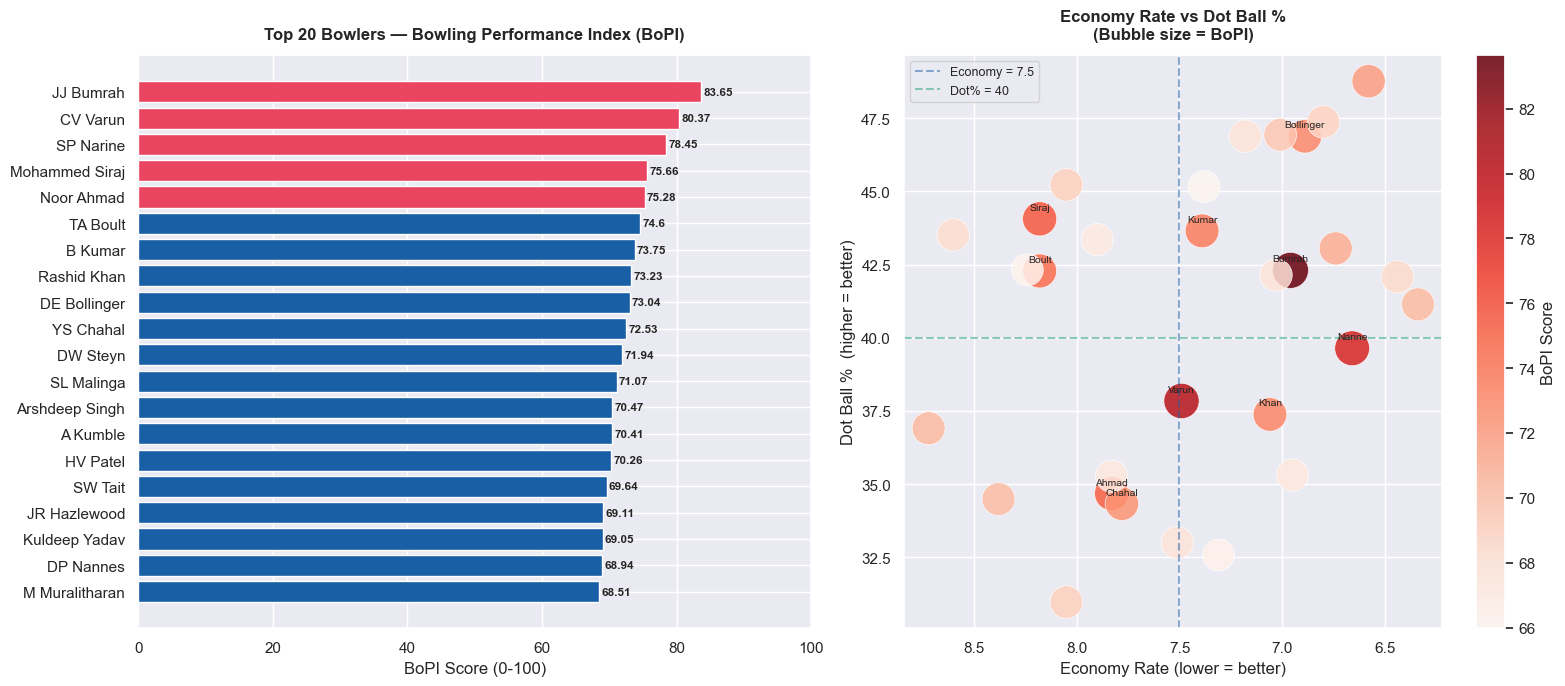

✅ Chart saved → screenshots/03_bowling_bopi.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top20 = bopi_df.head(20).sort_values('BoPI')
colors = ['#E94560' if i >= 15 else '#185FA5' for i in range(20)]

# Chart 1 — BoPI Ranking
axes[0].barh(top20['bowler'], top20['BoPI'], color=colors)
axes[0].set_title('Top 20 Bowlers — Bowling Performance Index (BoPI)',
                  fontweight='bold', pad=12)
axes[0].set_xlabel('BoPI Score (0-100)')
for i, (val, name) in enumerate(zip(top20['BoPI'], top20['bowler'])):
    axes[0].text(val + 0.3, i, f'{val}', va='center', fontsize=8.5, fontweight='bold')
axes[0].set_xlim(0, 100)

# Chart 2 — Economy vs Dot Ball % bubble chart
scatter_df = bopi_df.head(30)
scatter = axes[1].scatter(
    scatter_df['economy'],
    scatter_df['dot_pct'],
    s=scatter_df['BoPI'] * 8,
    c=scatter_df['BoPI'],
    cmap='Reds',
    alpha=0.85,
    edgecolors='white',
    linewidth=0.5
)
for _, row in scatter_df.head(10).iterrows():
    axes[1].annotate(
        row['bowler'].split()[-1],
        (row['economy'], row['dot_pct']),
        fontsize=7.5, ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points'
    )
plt.colorbar(scatter, ax=axes[1], label='BoPI Score')
axes[1].set_title('Economy Rate vs Dot Ball %\n(Bubble size = BoPI)',
                  fontweight='bold', pad=12)
axes[1].set_xlabel('Economy Rate (lower = better)')
axes[1].set_ylabel('Dot Ball %  (higher = better)')
axes[1].axvline(x=7.5, color='#185FA5', linestyle='--', alpha=0.5, label='Economy = 7.5')
axes[1].axhline(y=40, color='#1D9E75', linestyle='--', alpha=0.5, label='Dot% = 40')
axes[1].legend(fontsize=9)
axes[1].invert_xaxis()

plt.tight_layout()
plt.savefig('../screenshots/03_bowling_bopi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/03_bowling_bopi.png")

In [7]:
bowling_export = bopi_df[[
    'bowling_rank', 'bowler', 'matches', 'overs',
    'wickets', 'runs_conceded', 'economy', 'avg',
    'wicket_rate', 'dot_pct', 'boundary_pct',
    'powerplay_economy', 'powerplay_dot_pct', 'powerplay_wickets',
    'middle_economy', 'middle_dot_pct', 'middle_wickets',
    'death_economy', 'death_dot_pct', 'death_wickets',
    'recent_matches', 'recent_wickets', 'recent_economy', 'recent_dot_pct',
    'BoPI'
]].copy()

bowling_export.to_csv('../data/processed/bowling_stats.csv', index=False)

print(f"✅ Bowling stats exported → data/processed/bowling_stats.csv")
print(f"   Bowlers : {len(bowling_export)}")
print(f"   Columns : {len(bowling_export.columns)}")
print(f"\nNext → 03_player_index.ipynb")

✅ Bowling stats exported → data/processed/bowling_stats.csv
   Bowlers : 191
   Columns : 25

Next → 03_player_index.ipynb
